In [1]:
!python -m pip install transformers
!python -m pip install tensorflow scikit-learn pandas matplotlib
!pip install ipywidgets

#Import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import torch
import transformers as ppb
import warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import os
import matplotlib.pyplot as plt


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#參數設置區

#資料集、模型選擇參數設置區
dataSet = 'Final_XSS_Dataset' #選項有 'XSS_dataset'、'HttpParamsDataset'、'PortSwigger_XSSDataSet'、'XSSed_CSIC2010'、'Final_XSS_Dataset'
modelType = 'BERT' #選項有 'BERT'、'DistilBERT'

#I/O參數設置區

if dataSet == 'XSS_dataset':
  dataSetPath = r'../res/TrainingData/DataSet/XSS_dataset.csv'
elif dataSet == 'HttpParamsDataset':
  dataSetPath = r'../res/TrainingData/DataSetOfHttpParamsDataset/payload_train.csv'
elif dataSet == 'PortSwigger_XSSDataSet':
  dataSetPath = r'../res/TrainingData/Final_PortSwigger_XSSDataset(資料集內容待驗證)/PortSwigger_XSSDataSet.csv'
elif dataSet == 'XSSed_CSIC2010':
  dataSetPath = r'../res/TrainingData/Final_XSSed_CSIC2010FromKaggle(資料集內容待驗證)/XSSed_CSIC2010.csv'
elif dataSet == 'Final_XSS_Dataset':
  dataSetPath = r'../res/TrainingData/Final_XSSDataSet(資料集內容待驗證)/Final_XSS_dataset(Train).csv'

In [5]:
#載入資料集
df = pd.read_csv( dataSetPath, header = None )

In [6]:
#Loading Pre-trained Model

#Loading Pre-trained BERT Model:
if modelType == 'DistilBERT':
  model_class, tokenizer_class, pretrained_weights = ( ppb.DistilBertModel, ppb.DistilBertTokenizer, 'distilbert-base-uncased' )
elif modelType == 'BERT':
  model_class, tokenizer_class, pretrained_weights = ( ppb.BertModel, ppb.BertTokenizer, 'bert-base-uncased' )

# Load pretrained model/tokenizer
tokenizer = tokenizer_class.from_pretrained( pretrained_weights )
model = model_class.from_pretrained( pretrained_weights )

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to re

In [7]:
#Debugging Cell (You can use this cell to debug if you encounter any problems in tokenization)

index = 0

for element in df[0]:
    if type( element ) != type( 'str' ):
        print( 'In index ', index, ': The type of element is ', type( element ) )

    index = index + 1

In [8]:
#Tokenization
# tokenized = df[0].apply( ( lambda x: tokenizer.encode( x, add_special_tokens = True ) ) ) #Stable and crediable method
tokenized = df[0].apply( ( lambda x: tokenizer.encode( x, add_special_tokens = True, truncation = True, max_length = 600 ) ) ) # New and unstable method 

In [9]:
#Padding
padded = []
labels = []
index = 0
maxLen = 0

for token in tokenized.values:

  if len( token ) > maxLen:
    maxLen = len( token )

for token in tokenized.values:
    
  while len( token ) <= maxLen:

    if len( token ) < maxLen:
      token.append( 0 )

    else:
      padded.append( token )

      if dataSet == 'HttpParamsDataset' :
        labels.append( df.loc[ index, 3 ] )

      else:
        labels.append( df.loc[ index, 1 ] )
          
      break

  index = index + 1

padded = np.array( padded )
print( type( padded ) )
print( 'The maxium length is ', maxLen )

<class 'numpy.ndarray'>
The maxium length is  600


In [10]:
#如果是使用HttpParamsDataset資料集，對資料集的label作一點處理
if dataSet == 'HttpParamsDataset' : 
  print( 'The length of labels is ', len(labels) ) #Debug用

  templabels = [] #將label從字串轉換成整數用，具體作法是先從label list中取出一個label，將其轉換成整數後存進此list中。
                  #當所有label都轉成整數並存進此list後會再將label list重新指向此list。

  for index in range( 0, len( labels ), 1 ):

    if labels[index] == 'norm':
      templabels.append( 0 )

    elif labels[index] == 'anom':
      templabels.append( 1 )

  print( 'The length of templabels is ', len(templabels) ) #Debug用
  labels = templabels

In [11]:
#Debug(印label)
print( labels )

[0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 

In [12]:
#實作Transformer的Encoder(使用繼承方式建構神經層)
class TransformerEncoder( layers.Layer ):

    def __init__( self, embedDim, denseDim, numHeads, **kwargs  ): #不知為啥會多一個**kwargs
        super().__init__( **kwargs ) #別忘了要先呼叫父類別的初始化函式
                                     #不知為啥會多一個**kwargs

        #請在下方定義模型的神經層

        #STEP1:宣告並初始化與此神經層有關的變數
        self.embedDim = embedDim
        self.denseDim = denseDim
        self.numHeads = numHeads

        #STEP2:定義此神經層所含的元件的神經網路具體架構
        self.attention = layers.MultiHeadAttention (
                             num_heads = numHeads,
                             key_dim = embedDim
                         )

        self.layerNorm1 = layers.LayerNormalization()
        self.layerNorm2 = layers.LayerNormalization()

        self.dense1 = layers.Dense( denseDim, activation = "relu" )
        self.dense2 = layers.Dense( embedDim )

    # 在 call() 裡定義正向傳播的過程
    def call( self, inputs, mask = None ):

        #請在下方定義正向傳播的過程

        #STEP1:一些input資料必要的預處理

        #Embedding層生成的遮罩會是二維的，但 attention 層會期望接收三維的遮罩，
        #所以我們要增加其軸數(在第一軸增加一軸)
        if mask is not None:
            mask = mask[ :, tf.newaxis, : ]

        #STEP2:定義此神經層的正向傳播過程
        attentionOutput = self.attention( inputs, inputs, attention_mask = mask )
        projInput = self.layerNorm1( inputs + attentionOutput )
        projHiddenOutput1 = self.dense1( projInput )
        projOutput = self.dense2( projHiddenOutput1 )
        output = self.layerNorm2( projInput + projOutput )

        #STEP3:回傳此神經層的輸出值
        return output

    # 這個函式的功用請參考 [1] 的 p.11-47 ~ p.11-48
    def get_config( self ):
        config = super().get_config()
        config.update( {
                        "embedDim": self.embedDim,
                        "denseDim": self.denseDim,
                        "numHeads": self.numHeads,
                       } )
        return config

In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, length, inputDim, outputDim, **kwargs):
        super().__init__(**kwargs)
        self.tokenEmbeddings = layers.Embedding(input_dim=inputDim, output_dim=outputDim, mask_zero=True)
        self.positionEmbeddings = layers.Embedding(input_dim=length, output_dim=outputDim)
        self.length = length
        self.inputDim = inputDim
        self.outputDim = outputDim

    def call(self, inputs):
        # inputs 的預期形狀: (batch_size, sequence_length)

        # 獲取輸入張量在執行時的實際形狀 (使用 tf.shape)
        input_shape = tf.shape(inputs)
        # sequence_length 通常在第二個維度 (索引 1)
        seq_len = input_shape[1]

        # 創建位置序列 [0, 1, ..., seq_len-1]
        # tf.range 可以處理 Tensor 輸入作為 limit
        positions = tf.range(start=0, limit=seq_len, delta=1) # 形狀: (seq_len,)

        # 獲取 token 的嵌入向量 (會自動處理遮罩)
        # 輸出形狀: (batch_size, seq_len, outputDim)
        embeddedTokens = self.tokenEmbeddings(inputs)

        # 獲取位置的嵌入向量
        # 輸入形狀 (seq_len,) -> 輸出形狀 (seq_len, outputDim)
        embeddedPositions = self.positionEmbeddings(positions)

        # 將 token 嵌入和位置嵌入相加
        # TensorFlow/Keras 的廣播 (broadcasting) 機制會自動處理形狀不完全匹配的情況
        return embeddedTokens + embeddedPositions # 輸出形狀: (batch_size, seq_len, outputDim)


In [24]:
#實作包含Transformer Encoder的模型

#STEP1: 設計此模型的架構
inputs = keras.Input( shape = ( None, ), dtype = "int64" )
wordEmbedded = PositionalEmbedding( length = maxLen, inputDim=tokenizer.vocab_size, outputDim = 768 )( inputs )
transformerOutputs = TransformerEncoder( embedDim = 768, denseDim = 32, numHeads = 2 )( wordEmbedded )  
#上面那行程式碼的相關參數說明
#  embedDim: 輸入token的向量大小
#  denseDim: Transformer Encoder 內部的 Fully Connection 裡某一個 layer 的大小。           
#  numHeads: Attention heads 的數量
decreaseDimensionalSpaceOutput = layers.GlobalMaxPooling1D()( transformerOutputs )
hiddenLayersOutputs = layers.Dense( 64, activation = "relu" )( decreaseDimensionalSpaceOutput )
outputs = layers.Dense( 2, activation = 'softmax' )( hiddenLayersOutputs )

#STEP2: 把模型給實例化(instantiated)
model = keras.Model( inputs = inputs, outputs = outputs )
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_5          │ (None, None, 768)      │    23,901,696 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 768)      │     4,776,992 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 768)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,728,034 (109.59 MB)

 Trainable params: 28,728,034 (109.59 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#設置編譯參數
optimizer = tf.keras.optimizers.Adam( learning_rate = 0.0001 ) #這裡用的可能不是論文裡用的optimizer
loss = 'BinaryCrossentropy' #這裡用的可能不是論文裡用的loss function，
                            #目前考慮採用的loss function有
                            #  1) 'BinaryCrossentropy'
                            #  2) 'categorical_crossentropy'

#編譯model
model.compile( 
    optimizer = optimizer,
    loss = loss,
    metrics = [ 'accuracy', tf.keras.metrics.Recall() ] #這裡用的可能不是論文裡用的metrics 
)

In [26]:
#處理訓練與驗證資料並切割訓練資料集和驗證資料集

#處理訓練與驗證資料
labels = to_categorical( labels )

#切割訓練資料集和驗證資料集(此切法可能和論文裡的切法不同)
trainingData, validData, trainingLabel, validLabel = train_test_split( padded, np.array( labels ), test_size = 0.1 , shuffle = True )

#查看結果
print( 'Training data and label : ', trainingData.shape, trainingLabel.shape )
print( '驗證資料與label : ', validData.shape, validLabel.shape )

Training data and label :  (26779, 600) (26779, 2)
驗證資料與label :  (2976, 600) (2976, 2)


In [27]:
#訓練參數設置(此配置可能跟論文的配置不同)
epoch = 10
batchSize = 64

In [ ]:
callbacksList = [
    #以下這個callback為在每個週期結束後若val_loss有改善，則把當下的模型給存起來
    #簡單來說這個callback的目的就是希望可以把val_loss最好的那個週期的模型給存起來
    keras.callbacks.ModelCheckpoint( 
        filepath = "BestModel_Transformer.keras", #存檔的路徑及檔名
        monitor = "val_loss", #當val_loss有改善時才會儲存模型，別忘了若寫了這一行程式碼
                              #則一定要在此callback裡面也加上save_best_only = True這一
                              #行程式碼才行
        save_best_only = True, 
    )
]
model.save("BestModel_Transformer.keras")
history = model.fit(
              trainingData, #訓練資料，貌似需為NumPy陣列或DataSet物件
              trainingLabel, #訓練資料的label，貌似需為NumPy陣列或DataSet物件
              epochs = epoch,
              batch_size = batchSize, 
              callbacks = callbacksList,
              validation_data = ( validData, validLabel ) #驗證資料及其label需為NumPy陣列或DataSet物件
          ) 

Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 2028s 5s/step - accuracy: 0.9721 - loss: 0.1000 - recall_1: 0.9721 - val_accuracy: 0.9980 - val_loss: 0.0115 - val_recall_1: 0.9980
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 1919s 5s/step - accuracy: 0.9973 - loss: 0.0093 - recall_1: 0.9973 - val_accuracy: 0.9987 - val_loss: 0.0064 - val_recall_1: 0.9987
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 1884s 4s/step - accuracy: 0.9993 - loss: 0.0036 - recall_1: 0.9993 - val_accuracy: 0.9990 - val_loss: 0.0035 - val_recall_1: 0.9990
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 1998s 5s/step - accuracy: 0.9998 - loss: 0.0015 - recall_1: 0.9998 - val_accuracy: 0.9983 - val_loss: 0.0038 - val_recall_1: 0.9983
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 1885s 4s/step - accuracy: 1.0000 - loss: 7.2556e-04 - recall_1: 1.0000 - val_accuracy: 0.9983 - val_loss: 0.0047 - val_recall_1: 0.9983
Epoch 6/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 1937s 5s/step - accuracy: 1.0000 - loss: 3.4704e-04 - recall_1: 1.0000 - val_accuracy: 0.9990 - 

In [29]:
#Debug用
'''
from keras.models import Model

#取某一层的输出为输出新建为model，采用函数模型
hidden_layer_model = Model( inputs = model.input,
                                     outputs = model.get_layer( 'global_max_pooling1d' ).output )
#以这个model的预测值作为输出
hidden_layer_output = hidden_layer_model.predict( validData )
'''

"\nfrom keras.models import Model\n\n#取某一层的输出为输出新建为model，采用函数模型\nhidden_layer_model = Model( inputs = model.input,\n                                     outputs = model.get_layer( 'global_max_pooling1d' ).output )\n#以这个model的预测值作为输出\nhidden_layer_output = hidden_layer_model.predict( validData )\n"

In [30]:
#Debug用
'''
print( ' The shape of hidden_layer_output is : ', hidden_layer_output.shape )
print( ' The length of hidden_layer_output is : ', len( hidden_layer_output ) )

numOfPositiveSample = 0
numOfNegativeSample = 0
averagePositiveOutput = np.zeros( len( hidden_layer_output[0] ) )
averageNegativeOutput = np.zeros( len( hidden_layer_output[0] ) )
print( 'The shape of averagePositiveOutput is : ', averagePositiveOutput.shape )
print( 'The shape of averageNegativeOutput is : ', averageNegativeOutput.shape )
print()

#加總
for index in range( 0, len(hidden_layer_output), 1 ):

    if validLabel[index][0] == 1 and validLabel[index][1] == 0:
        averageNegativeOutput = averageNegativeOutput + hidden_layer_output[index]
        numOfNegativeSample = numOfNegativeSample + 1

    elif validLabel[index][0] == 0 and validLabel[index][1] == 1:
        averagePositiveOutput = averagePositiveOutput + hidden_layer_output[index]
        numOfPositiveSample = numOfPositiveSample + 1

#除以樣本數以計算平均值
for index in range( 0, numOfNegativeSample, 1 ):
    averageNegativeOutput[index] = averageNegativeOutput[index] / numOfNegativeSample

for index in range( 0, numOfPositiveSample, 1 ):
    averagePositiveOutput[index] = averagePositiveOutput[index] / numOfPositiveSample

print( 'The average of negative output is:' )
print( averageNegativeOutput )
print( 'The amount of negative samples is ', numOfNegativeSample )
print( 'The average of positive output is:' )
print( averagePositiveOutput )
print( 'The amount of positive samples is ', numOfPositiveSample )

#試圖找出正向樣本與副向樣本的差異

# for payloadOutput in hidden_layer_output:
#     print( type( payloadOutput ) )
'''

"\nprint( ' The shape of hidden_layer_output is : ', hidden_layer_output.shape )\nprint( ' The length of hidden_layer_output is : ', len( hidden_layer_output ) )\n\nnumOfPositiveSample = 0\nnumOfNegativeSample = 0\naveragePositiveOutput = np.zeros( len( hidden_layer_output[0] ) )\naverageNegativeOutput = np.zeros( len( hidden_layer_output[0] ) )\nprint( 'The shape of averagePositiveOutput is : ', averagePositiveOutput.shape )\nprint( 'The shape of averageNegativeOutput is : ', averageNegativeOutput.shape )\nprint()\n\n#加總\nfor index in range( 0, len(hidden_layer_output), 1 ):\n\n    if validLabel[index][0] == 1 and validLabel[index][1] == 0:\n        averageNegativeOutput = averageNegativeOutput + hidden_layer_output[index]\n        numOfNegativeSample = numOfNegativeSample + 1\n\n    elif validLabel[index][0] == 0 and validLabel[index][1] == 1:\n        averagePositiveOutput = averagePositiveOutput + hidden_layer_output[index]\n        numOfPositiveSample = numOfPositiveSample + 1\n\n

In [31]:
#Debug用
'''
print( hidden_layer_output.shape )

index = 0

for element in hidden_layer_output:
    for element2 in element:
        if index == 0:
            print( element2 )
    index = index + 1
'''

'\nprint( hidden_layer_output.shape )\n\nindex = 0\n\nfor element in hidden_layer_output:\n    for element2 in element:\n        if index == 0:\n            print( element2 )\n    index = index + 1\n'

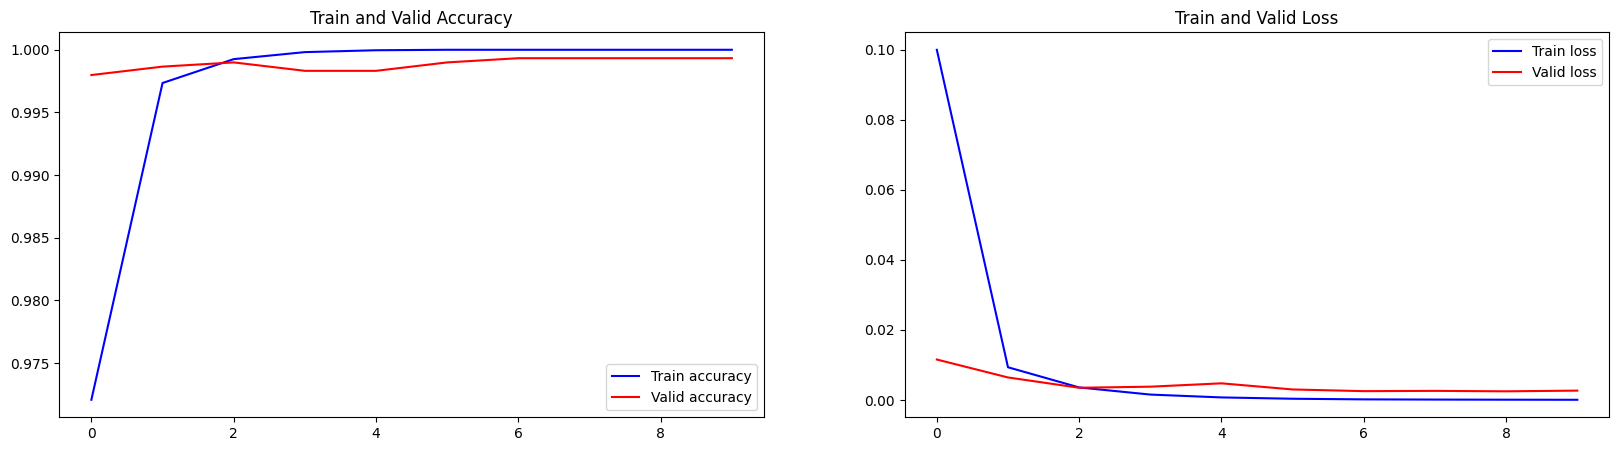

In [32]:
# Plot training and validating accuracy and loss curve
h = history.history
epochs = range( len ( h['loss'] ) )

plt.figure( figsize = ( 20, 5 ) )
ax = plt.subplot( 1, 2, 1 )
ax.set_title( 'Train and Valid Accuracy' )
plt.plot( epochs, h['accuracy'], 'b', label='Train accuracy' )
plt.plot( epochs, h['val_accuracy'], 'r', label='Valid accuracy' )
plt.legend()

ax = plt.subplot(1, 2, 2)
ax.set_title('Train and Valid Loss')
plt.plot(epochs, h['loss'], 'b', label='Train loss')
plt.plot(epochs, h['val_loss'], 'r', label='Valid loss')
plt.legend()

plt.savefig(f'Train_Valid_ACCandLOSS_TransformerEncoder_PositionalEmbedding.png')

plt.show()

dict_keys(['accuracy', 'loss', 'recall_1', 'val_accuracy', 'val_loss', 'val_recall_1'])


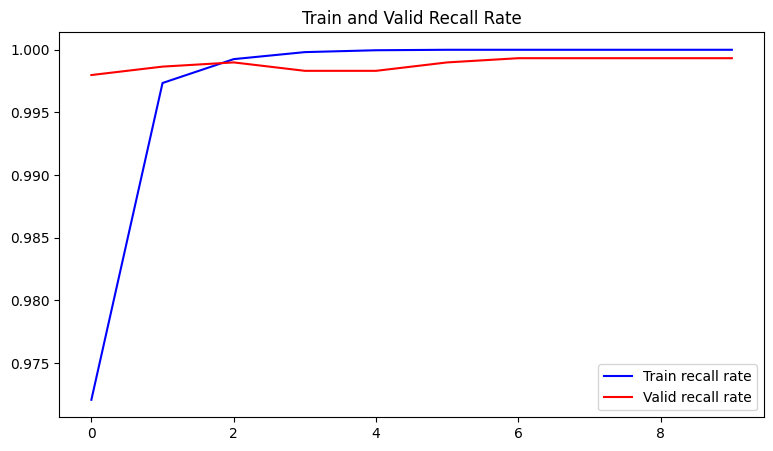

In [ ]:
# Plot training and validating recall curve
h = history.history
epochs = range( len ( h['loss'] ) )

plt.figure( figsize = ( 20, 5 ) )
ax = plt.subplot( 1, 2, 1 )
ax.set_title( 'Train and Valid Recall Rate' )
plt.plot( epochs, h['recall_1'], 'b', label='Train recall rate' )
plt.plot( epochs, h['val_recall_1'], 'r', label='Valid recall rate' )
plt.legend()

plt.savefig(f'Train_Valid_Recall_TransformerEncoder_PositionalEmbedding.png')

plt.show()